# Relations: Reflexive, Symmetric, Transitive

## 1. 기본 정의 
 **Relation(관계)** R on set A: A × A의 부분집합
- **Reflexive**: ∀a ∈ A, (a,a) ∈ R
- **Symmetric**: ∀a,b ∈ A, (a,b) ∈ R ⇒ (b,a) ∈ R  
- **Transitive**: ∀a,b,c ∈ A, (a,b) ∈ R ∧ (b,c) ∈ R ⇒ (a,c) ∈ R

---

## 2. 수학적 예제

### 예제 1: 정수 집합 ℤ에서의 관계 
**R₁ = "같다" 관계**: {(x,y) | x = y}
- Reflexive: ✅ x = x (항상 참)
- Symmetric: ✅ x = y ⇒ y = x  
- Transitive: ✅ x = y ∧ y = z ⇒ x = z

**R₂ = "≤" 관계**: {(x,y) | x ≤ y}
- Reflexive: ✅ x ≤ x
- Symmetric: ❌ x ≤ y ⇒ y ≤ x? (거짓: 1 ≤ 2지만 2 ≤ 1 아님)
- Transitive: ✅ x ≤ y ∧ y ≤ z ⇒ x ≤ z

**R₃ = "<" 관계**: {(x,y) | x < y}  
- Reflexive: ❌ x < x? (거짓)
- Symmetric: ❌ x < y ⇒ y < x? (거짓)
- Transitive: ✅ x < y ∧ y < z ⇒ x < z

---

### 예제 2: 집합 A = {1,2,3,4}에서의 관계 분석
**R₄ = {(1,1), (2,2), (3,3), (1,2), (2,1), (2,3), (3,2)}** 
- **Reflexive 검증**:
   - 필요한 쌍: (1,1), (2,2), (3,3), (4,4)
   - 없는 쌍: (4,4) ❌
 
- **Symmetric 검증**:
   - (1,2) ∈ R ⇒ (2,1) ∈ R? ✅
   - (2,3) ∈ R ⇒ (3,2) ∈ R? ✅
   - 모든 쌍이 대칭적 ✅
 
- **Transitive 검증**:
   - (1,2) ∈ R ∧ (2,3) ∈ R ⇒ (1,3) ∈ R? ❌ (1,3) 없음
   - (2,3) ∈ R ∧ (3,2) ∈ R ⇒ (2,2) ∈ R? ✅
 
**결론**: Symmetric만 만족

---

## 3. 행렬 표현으로 이해하기

In [7]:
import numpy as np

# 관계 R = {(1,1), (1,2), (2,2), (2,3), (3,3)} on {1,2,3}
relation_matrix = np.array([
    [1, 1, 0],  # 1→1, 1→2
    [0, 1, 1],  # 2→2, 2→3  
    [0, 0, 1]   # 3→3
])

print("Relation Matrix:")
print(relation_matrix)

Relation Matrix:
[[1 1 0]
 [0 1 1]
 [0 0 1]]


### 행렬로 성질 판별:
- **Reflexive**: 주대각선이 모두 1
- **Symmetric**: 행렬이 대칭행렬
- **Transitive**: R² ⊆ R (R∘R ⊆ R)

---

## 4. 함수와의 관계

### 동치관계(Equivalence Relation)

Reflexive + Symmetric + Transitive를 모두 만족하면 동치관계
 
**예시**: 
- 정수에서 "n으로 나눈 나머지가 같다" (합동 관계)
- 그래프에서 "연결되어 있다" 관계
- 집합에서 "크기가 같다" 관계

### 부분순서관계(Partial Order)
Reflexive + Antisymmetric + Transitive

**예시**:
- 집합에서 "부분집합" 관계 (⊆)
- 정수에서 "나누다" 관계 (|)
- 실수에서 "≤" 관계

---

## 5. 추이적 폐포(Transitive Closure)

In [8]:
def transitive_closure(matrix):
    """Warshall 알고리즘으로 추이적 폐포 계산"""
    n = len(matrix)
    closure = matrix.copy()
    
    for k in range(n):
        for i in range(n):
            for j in range(n):
                closure[i][j] = closure[i][j] or (closure[i][k] and closure[k][j])
    
    return closure

# 예시: R = {(1,2), (2,3)}
R = np.array([
    [0, 1, 0],
    [0, 0, 1], 
    [0, 0, 0]
])

print("Original R:")
print(R)
print("Transitive Closure:")
print(transitive_closure(R))

Original R:
[[0 1 0]
 [0 0 1]
 [0 0 0]]
Transitive Closure:
[[0 1 1]
 [0 0 1]
 [0 0 0]]


---

## 6. 실전 문제


#### 문제
집합 S = {a,b,c,d}에서 관계 R이 다음과 같을 때, 각 성질을 판별하라.

R = {(a,a), (b,b), (c,c), (d,d), (a,b), (b,a), (b,c), (c,b), (a,c), (c,a)}

#### 풀이:
1. **Reflexive**: (a,a), (b,b), (c,c), (d,d) 모두 존재 ✅

2. **Symmetric**: 
    - (a,b)∈R ⇒ (b,a)∈R ✅
    - (b,c)∈R ⇒ (c,b)∈R ✅  
    - (a,c)∈R ⇒ (c,a)∈R ✅

3. **Transitive**:
   - (a,b)∈R ∧ (b,c)∈R ⇒ (a,c)∈R? ✅
   - 모든 삼중조 검증 통과 ✅

#### 결론
세 성질 모두 만족 → **동치관계**

---
## 7. 중요 정리
 
- **동치관계**는 집합을 **동치류**로 분할함
- **부분순서**는 요소들 간의 **계층 구조**를 정의함  
- 관계의 성질들은 **대수적 구조**와 **그래프 이론**의 기초가 됨

1. 관계(Relation)란?
그냥 '짝 지어주는 규칙'이에요
예: (1,2) → 1하고 2는 짝
예: (서울, 한국) → 서울은 한국에 속함

2. 세 가지 성질
(1) Reflexive (반사적)
모든 원소는 자기 자신과 짝
필수 조건: (1,1), (2,2), (3,3) 이 모두 있어야 함
✅ 예: 같은 숫자다 관계
❌ 반례: 더 크다 관계 - 1 > 1? 아니잖아!

(2) Symmetric (대칭적)
A-B 짝이면 B-A 짝도 있어야 함
조건: (1,2)가 있으면 (2,1)도 있어야 함
✅ 예: 결혼했다 관계 - A와 B가 결혼 → B와 A도 결혼
❌ 반례: 부모다 관계 - A가 B의 부모 ≠ B가 A의 부모

(3) Transitive (추이적)
A-B 짝이고 B-C 짝이면 A-C 짝도 있어야 함
조건: (1,2) 있고 (2,3) 있으면 (1,3)도 있어야 함
✅ 예: 같은 반이다 관계
❌ 반례: 부모다 관계 - A가 B의 부모, B가 C의 부모 → A는 C의 조부모

3. 예제 분석
관계: [(1, 1), (2, 2), (3, 3), (1, 2), (2, 1), (2, 3), (3, 2)]
Reflexive: ✅
Symmetric: ✅
Transitive: ❌

4. 관계 그래프 시각화
빨간색 원: 자기 자신과의 관계 (Reflexive)
파란색 화살표: 다른 원소와의 관계


/var/folders/73/yy8lvrgj27zbjsd0whjkxm700000gn/T/ipykernel_16218/312416631.py:118: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/73/yy8lvrgj27zbjsd0whjkxm700000gn/T/ipykernel_16218/312416631.py:118: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/73/yy8lvrgj27zbjsd0whjkxm700000gn/T/ipykernel_16218/312416631.py:118: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/73/yy8lvrgj27zbjsd0whjkxm700000gn/T/ipykernel_16218/312416631.py:118: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/73/yy8lvrgj27zbjsd0whjkxm700000gn/T/ipykernel_16218/312416631.py:118: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/73/yy8lvrgj27zbjsd0whjkxm700000gn/T/ipykern

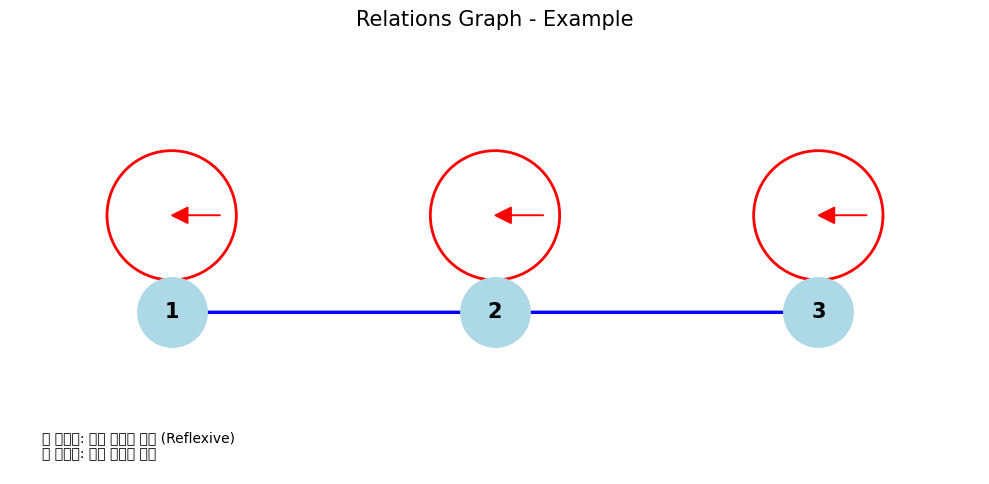


5. 다른 예제들
예제 1: 완전한 동치관계 (세 가지 모두 만족)


/var/folders/73/yy8lvrgj27zbjsd0whjkxm700000gn/T/ipykernel_16218/312416631.py:118: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/june/.pyenv/versions/3.11.5/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


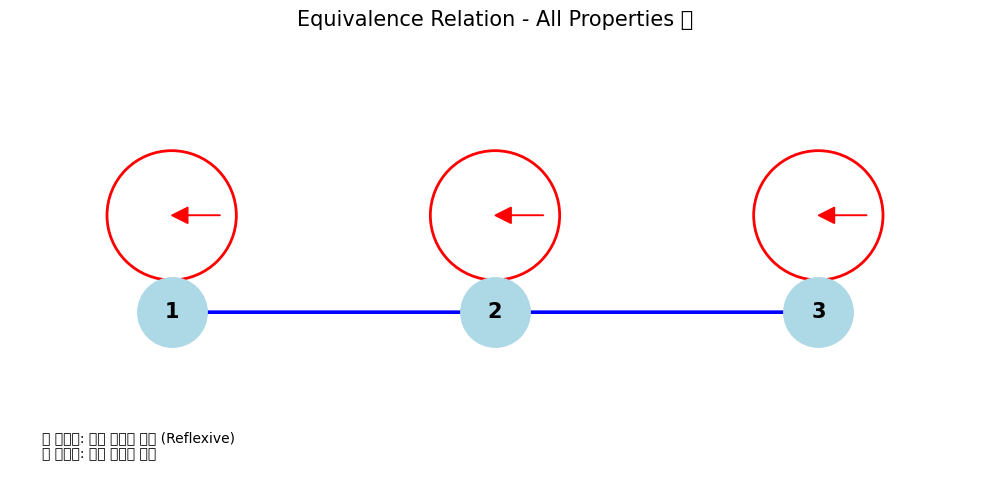

예제 2: Transitive만 만족


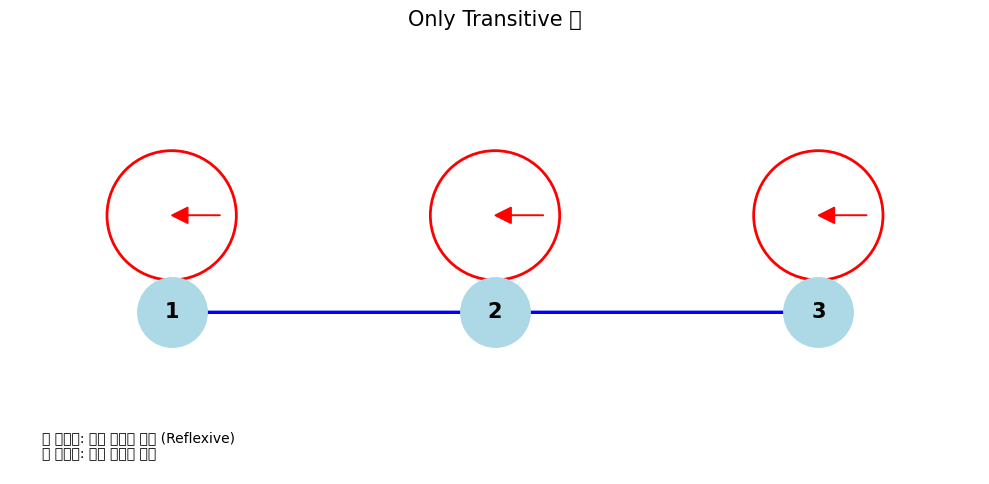


6. 핵심 요약
Reflexive: 모든 원소는 자기 자신과 관계있음
Symmetric: 관계가 양방향으로 작용함
Transitive: 관계가 연결되어 전달됨


In [9]:
# Relations (관계) - 초간단 설명 + 시각화 (networkx 없이)

import matplotlib.pyplot as plt

# 1. 관계(Relation)가 뭔가요?
print("1. 관계(Relation)란?")
print("그냥 '짝 지어주는 규칙'이에요")
print("예: (1,2) → 1하고 2는 짝")
print("예: (서울, 한국) → 서울은 한국에 속함")
print()

# 2. 세 가지 성질 설명
print("2. 세 가지 성질")

print("(1) Reflexive (반사적)")
print("모든 원소는 자기 자신과 짝")
print("필수 조건: (1,1), (2,2), (3,3) 이 모두 있어야 함")
print("✅ 예: 같은 숫자다 관계")
print("❌ 반례: 더 크다 관계 - 1 > 1? => NOOO")
print()

print("(2) Symmetric (대칭적)")
print("A-B 짝이면 B-A 짝도 있어야 함")
print("조건: (1,2)가 있으면 (2,1)도 있어야 함")
print("✅ 예: 결혼했다 관계 - A와 B가 결혼 → B와 A도 결혼")
print("❌ 반례: 부모다 관계 - A가 B의 부모 ≠ B가 A의 부모")
print()

print("(3) Transitive (추이적)")
print("A-B 짝이고 B-C 짝이면 A-C 짝도 있어야 함")
print("조건: (1,2) 있고 (2,3) 있으면 (1,3)도 있어야 함")
print("✅ 예: 같은 반이다 관계")
print("❌ 반례: 부모다 관계 - A가 B의 부모, B가 C의 부모 → A는 C의 조부모")
print()

# 3. 예제 관계 정의
relations = [(1,1), (2,2), (3,3), (1,2), (2,1), (2,3), (3,2)]

# 4. 성질 체크 함수
def check_properties(relations, elements):
    reflexive = True
    symmetric = True
    transitive = True
    
    # Reflexive 체크
    for elem in elements:
        if (elem, elem) not in relations:
            reflexive = False
            break
    
    # Symmetric 체크
    for (a, b) in relations:
        if (b, a) not in relations:
            symmetric = False
            break
    
    # Transitive 체크
    for (a, b) in relations:
        for (c, d) in relations:
            if b == c and (a, d) not in relations:
                transitive = False
                break
    
    return reflexive, symmetric, transitive

# 5. 결과 출력
elements = [1, 2, 3]
reflexive, symmetric, transitive = check_properties(relations, elements)

print("3. 예제 분석")
print(f"관계: {relations}")
print(f"Reflexive: {'✅' if reflexive else '❌'}")
print(f"Symmetric: {'✅' if symmetric else '❌'}")
print(f"Transitive: {'✅' if transitive else '❌'}")
print()

# 6. 간단한 시각화 (networkx 없이)
def draw_simple_graph(relations, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 노드 위치 설정
    nodes = {1: (1, 2), 2: (2, 2), 3: (3, 2)}
    
    # 노드 그리기
    for node, pos in nodes.items():
        ax.plot(pos[0], pos[1], 'o', markersize=50, color='lightblue')
        ax.text(pos[0], pos[1], str(node), ha='center', va='center', fontsize=15, fontweight='bold')
    
    # 관계(엣지) 그리기
    for (a, b) in relations:
        if a == b:  # 자기 자신과의 관계 (Reflexive)
            # 원형 화살표 그리기
            circle = plt.Circle((nodes[a][0], nodes[a][1] + 0.3), 0.2, 
                              color='red', fill=False, linewidth=2)
            ax.add_patch(circle)
            # 화살표 머리
            ax.arrow(nodes[a][0] + 0.15, nodes[a][1] + 0.3, -0.1, 0, 
                    head_width=0.05, head_length=0.05, fc='red', ec='red')
        else:
            # 다른 노드와의 관계
            start = nodes[a]
            end = nodes[b]
            # 화살표 그리기
            ax.arrow(start[0], start[1], end[0]-start[0], end[1]-start[1],
                    head_width=0.05, head_length=0.05, fc='blue', ec='blue',
                    length_includes_head=True, linewidth=2)
    
    ax.set_xlim(0.5, 3.5)
    ax.set_ylim(1.5, 2.8)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=15, pad=20)
    ax.axis('off')
    
    # 범례
    ax.text(0.6, 1.6, '🔴 빨간색: 자기 자신과 관계 (Reflexive)', fontsize=10)
    ax.text(0.6, 1.55, '🔵 파란색: 다른 원소와 관계', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# 7. 그래프 그리기
print("4. 관계 그래프 시각화")
print("빨간색 원: 자기 자신과의 관계 (Reflexive)")
print("파란색 화살표: 다른 원소와의 관계")
draw_simple_graph(relations, "Relations Graph - Example")

# 8. 다른 예제들도 시각화
print("\n5. 다른 예제들")

# 예제 1: 완전한 동치관계
print("예제 1: 완전한 동치관계 (세 가지 모두 만족)")
equiv_relations = [(1,1), (2,2), (3,3), (1,2), (2,1), (2,3), (3,2), (1,3), (3,1)]
draw_simple_graph(equiv_relations, "Equivalence Relation - All Properties ✅")

# 예제 2: Transitive만 만족
print("예제 2: Transitive만 만족")
trans_only = [(1,1), (2,2), (3,3), (1,2), (2,3), (1,3)]
draw_simple_graph(trans_only, "Only Transitive ✅")

# 9. 핵심 요약
print("\n6. 핵심 요약")
print("Reflexive: 모든 원소는 자기 자신과 관계있음")
print("Symmetric: 관계가 양방향으로 작용함")  
print("Transitive: 관계가 연결되어 전달됨")